# Python vizualizācija — Matplotlib, Seaborn un Plotly

Šī piezīmju grāmata (notebook) ir paredzēta lekcijai **“Python vizualizācija”** un balstās uz kursa aprakstu:
- Matplotlib pamati
- Seaborn statistiskās vizualizācijas
- Interaktīvās vizualizācijas ar Plotly
- Prezentācijām piemēroti grafiki

Konteksts: studenti iepriekšējā nodarbībā jau ir strādājuši ar **Pandas**, **Jupyter Notebooks** un **Google Colab**.

## Mācību mērķi
Pēc šīs nodarbības studentam jāspēj:
1. izveidot skaidru statisku grafiku ar **Matplotlib**;
2. izmantot **Seaborn** statistiskai datu izpētei;
3. izveidot interaktīvu grafiku ar **Plotly**;
4. izvēlēties piemērotu grafika tipu konkrētam jautājumam;
5. ievērot pamata labās prakses principus profesionālās vizualizācijās.

## Datu kopa
Tiek izmantota sintētiska, bet reālistiska datu kopa par reģioniem, izdevumu kategorijām un iedzīvotāju apmierinātību Latvijā.

**Fails:** `python_vizualizacija_dati.csv`


## 1. Sagatavošanās

Šajā sadaļā importēsim vajadzīgās bibliotēkas un ielādēsim datus.


In [ ]:
# Ja strādājat Google Colab un nepieciešams Plotly/Seaborn jaunāks variants,
# var atkomentēt nākamo rindu:
# !pip install seaborn plotly -q

# šīs bibliotekas nav iebūvētas Python standarta bibliotēkā, 
# tāpēc tās ir jāinstalē, ja vēl nav pieejamas.
print("Ja ir kļūda tad bibliotēkas nav pieejamas, lūdzu instalējiet tās pirms turpināt.")
print("Instalējam no komandrindas, ja nepieciešams:")
# we also need openpyxl for reading Excel files, but in this case we are using CSV, so it's not required.
print("pip install pandas numpy matplotlib seaborn plotly openpyxl")
# Google Colab tām jau būtu jābūt pieejamām, bet vietējā vidē var būt nepieciešams tās instalēt.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ja nestrādā kāda no bibliotekām, var atkomentēt nākamo rindu un instalēt trūkstošo bibliotēku
print("Bibliotēkas ir pieejamas un gatavas lietošanai!")


# Labāka attēlu kvalitāte Jupyter/Colab vidē
plt.rcParams["figure.dpi"] = 130
sns.set_theme(style="whitegrid")

# Mēģinām nolasīt ārējo CSV failu.
# Ja fails nav pieejams, izveidojam to no iekšā definēta saraksta.
try:
    df = pd.read_csv("python_vizualizacija_dati.csv")
except FileNotFoundError: # plāns B, ja fails nav pieejams
    df = pd.read_csv("https://raw.githubusercontent.com/ValRCS/RTU_Digitalas_Prasmes_Excel_VBA_Python/refs/heads/main/notebooks/python_vizualizacija_dati.csv")

df.head()


Bibliotēkas ir pieejamas un gatavas lietošanai!


,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


## 2. Datu iepazīšana

Pirms veidot grafikus, vienmēr jāsaprot:
- kādas ir kolonnas,
- kādi ir datu tipi,
- vai ir tukšas vērtības,
- kāds jautājums vispār tiek uzdots datiem.


In [4]:
# Izpētiet datu struktūru
df.info()

# Papildu uzdevums:
# apskatiet pirmās 5 rindas un aprakstiet, ko nozīmē katra kolonna
# df.head()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   gads                       150 non-null    int64  
 1   regions                    150 non-null    str    
 2   kategorija                 150 non-null    str    
 3   izdevumi_milj_eur          150 non-null    float64
 4   projektu_skaits            150 non-null    int64  
 5   iedzivotaju_apmierinatiba  150 non-null    float64
 6   pakalpojuma_lietotaji      150 non-null    int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 8.3 KB


In [5]:
df.describe() # parāda tikai skaitliskās kolonnas, bet ne kategoriskās

,gads,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,2022.500000,48.785200,8.066667,72.535333,43824.573333
std,1.713547,17.099131,3.142407,6.730718,15914.491051
min,2020.000000,16.020000,2.000000,56.200000,11022.000000
25%,2021.000000,35.672500,6.000000,67.325000,32325.250000
50%,2022.500000,48.950000,8.000000,72.100000,44037.000000
75%,2024.000000,60.442500,10.000000,77.275000,52782.500000
max,2025.000000,94.820000,16.000000,87.700000,88660.000000


In [6]:
# kā parādīt visas kolonnas, ieskaitot kategoriskās?
df.describe(include="all")

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
count,150.000000,150,150,150.000000,150.000000,150.000000,150.000000
unique,NaN,5,5,NaN,NaN,NaN,NaN
top,NaN,Rīga,Izglītība,NaN,NaN,NaN,NaN
freq,NaN,30,30,NaN,NaN,NaN,NaN
mean,2022.500000,NaN,NaN,48.785200,8.066667,72.535333,43824.573333
std,1.713547,NaN,NaN,17.099131,3.142407,6.730718,15914.491051
min,2020.000000,NaN,NaN,16.020000,2.000000,56.200000,11022.000000
25%,2021.000000,NaN,NaN,35.672500,6.000000,67.325000,32325.250000
50%,2022.500000,NaN,NaN,48.950000,8.000000,72.100000,44037.000000
75%,2024.000000,NaN,NaN,60.442500,10.000000,77.275000,52782.500000


In [8]:
# kā šādu pārskatu saglabāt kā CSV failu?
# papildus Transponējam, lai kolonnas būtu rindās un saglabājam ar indeksu, lai saglabātu informāciju par kolonnu nosaukumiem
df.describe(include="all").T.to_csv("datu_apraksts.csv", index=True) # indekss šeit vajadzīgs, lai saglabātu informāciju par kolonnu nosaukumiem
# atceramies ka Google Colab vidē šis fails būs pieejams tikai sesijas laikā, bet vietējā vidē tas būs pieejams pastāvīgi.
# ja esat Google Colab tad vajadzēs vēl lejuplādēt šo failu, lai to varētu apskatīt ārpus Colab vidē. To var izdarīt ar šādu kodu:
# lokāli google.colab bibliotēka nav pieejama, tāpēc šo rindu var atkomentēt tikai Google Colab vidē.
# from google.colab import files
# files.download("datu_apraksts.csv")

## 3. Labā prakse vizualizācijās

Pirms ķeramies pie bibliotēkām, paturiet prātā dažus principus.

### Pamatprincipi
1. **Grafikam jāatbild uz jautājumu**, nevis vienkārši jāizskatās iespaidīgi.
2. **Izvēlieties pareizo grafika tipu**:
   - laika rindām — line chart jeb līniju diagramma,
   - kategoriju salīdzināšanai — bar chart jeb stabiņu diagramma,
   - sadalījumiem — histogramma vai boxplot (latviski — kastīšu diagramma),
   - sakarībām starp skaitliskiem mainīgajiem — scatter plot jeb punktu diagramma.
3. **Nepārslogojiet grafiku** ar pārāk daudz krāsām, etiķetēm un dekorācijām.
4. **Nosaukums, asu nosaukumi un leģenda** nav izvēles greznība — tie ir obligāti.
5. **Krāsu lietojumam jābūt semantiski pamatotam**.
6. **Prezentācijām** vajag lielākus fontus, mazāk sīku detaļu un vienu galveno domu vienā grafikā.


## 4. Matplotlib pamati

Šajā sadaļā veidosiet savus pirmos statiskos grafikus.


### Uzdevums 4.1. Līniju grafiks pa gadiem

Izveidojiet tabulu, kur katram gadam ir aprēķināta **kopējā izdevumu summa**, un uzzīmējiet to kā līniju grafiku.

**Prasības:**
- izmantojiet `groupby()`,
- uzlieciet virsrakstu,
- nosauciet abas asis,
- pievienojiet režģi.


In [9]:
# parādam galvu atkal
df.head()

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


In [ ]:
# pirms Group By es varēju veikt value counts gads kolonai, lai redzētu cik ierakstu ir katram gadam
df["gads"].value_counts()
# redzam cik katrā gadā ir ierakstu, un varam secināt, ka mums ir vienmērīgi sadalīti dati pa gadiem, kas ir labi, jo tas ļauj mums veikt salīdzinājumus starp gadiem bez bažām par datu trūkumu kādā gadā.

gads
2020    25
2021    25
2022    25
2023    25
2024    25
2025    25
Name: count, dtype: int64

In [ ]:
# TODO:
# 1. Izveidojiet DataFrame izdevumi_pa_gadiem
izdevumi_pa_gadiem = df.groupby("gads")["izdevumi_milj_eur"].sum().reset_index()
# parādam šo jauno DataFrame sākumu
izdevumi_pa_gadiem.head(15) # mums jau tikai 6 gadi



,gads,izdevumi_milj_eur
0,2020,1067.05
1,2021,1140.99
2,2022,1201.90
3,2023,1254.20
4,2024,1296.78
5,2025,1356.86


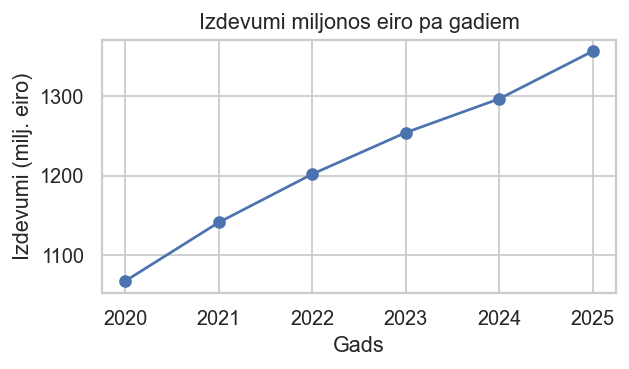

In [ ]:
# 2. Uzzīmējiet līniju grafiku ar matplotlib

# Jūsu kods šeit
import matplotlib.pyplot as plt # zīmējam grafiku ar matplotlib
plt.figure(figsize=(5, 3)) # iestatām grafika izmēru
# tagad izdomājam kas ir x un kas ir y
# x ir gads, y ir izdevumi_milj_eur
plt.plot(izdevumi_pa_gadiem["gads"], izdevumi_pa_gadiem["izdevumi_milj_eur"], marker="o") # zīmējam līniju grafiku ar punktiem
# jāatceras ka matplotlib vizualizācijas ir aktuālas vienas šūnas ietvaros, 
# tāpēc ja mēs izveidosim jaunu grafiku, tad iepriekšējais tiks pārrakstīts, 
# tāpēc šeit mēs varam redzēt tikai vienu grafiku, un tas ir šis līniju grafiks.
#  Ja mēs vēlāk izveidosim citu grafiku, tad šis līniju grafiks vairs nebūs redzams, jo tas tiks pārrakstīts ar jauno grafiku. Tas ir svarīgi atcerēties, jo dažreiz var šķist, ka grafiks nav izveidots, 
# bet patiesībā tas ir izveidots, bet pēc tam pārrakstīts ar citu grafiku.
# uzstādam grafika nosaukumu un asu nosaukumus
plt.title("Izdevumi miljonos eiro pa gadiem")
plt.xlabel("Gads")
plt.ylabel("Izdevumi (milj. eiro)")
# varam arī saglabāt šo grafiku kā attēlu, ja vēlamies to izmantot ārpus Python vidē
# pieliekam nedaudz tapsējumu (padding) lai nebūtu pārāk tuvu malām
plt.tight_layout()
plt.savefig("izdevumi_pa_gadiem.png", dpi=300) # saglabāt ar attiēla kvalitāti 300 dpi, kas ir laba kvalitāte drukāšanai
# parādam grafiku, var arī nerādit, ja tikai glabājam, bet šeit mēs gribam parādīt, tāpēc izmantojam plt.show()
plt.show()

### Uzdevums 4.2. Stabiņu grafiks pa kategorijām

Izveidojiet grafiku, kas salīdzina **kopējos izdevumus pa kategorijām**.

**Padoms:** pirms zīmēšanas sakārtojiet rezultātu dilstošā secībā.


In [21]:
df.head()

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


In [23]:
# uzmetam aci kategorija value counts
df["kategorija"].value_counts()

kategorija
Izglītība              30
Veselība               30
Transports             30
Kultūra                30
Sociālā aizsardzība    30
Name: count, dtype: int64

In [ ]:
# TODO:
# 1. Grupējiet datus pēc kategorijas
# 2. Saskaitiet izdevumus
izdevumi_pa_kategorijam = df.groupby("kategorija")["izdevumi_milj_eur"].sum().reset_index()
# apskatamies šos datus
izdevumi_pa_kategorijam.head()



,kategorija,izdevumi_milj_eur
0,Izglītība,1768.67
1,Kultūra,783.39
2,Sociālā aizsardzība,1203.84
3,Transports,1560.44
4,Veselība,2001.44


In [ ]:
# 3. Sakārtojiet rezultātu dilstoši pēc izdevumiem
# ja lietojam inplace=True, tad šī funkcija sakārto esošo DataFrame, neizveidojot jaunu, un tas ir efektīvāk, jo nav jāizveido jauns DataFrame, bet jāatceras, ka šī funkcija maina esošo DataFrame, tāpēc pēc tās izsaukšanas izdevumi_pa_kategorijam būs sakārtots pēc izdevumiem dilstoši.
# by="izdevumi_milj_eur" ir kolonna pēc kuras sakārtojam, ascending=False ir dilstošā secībā, inplace=True ir lai sakārtotu esošo DataFrame, neizveidojot jaunu
izdevumi_pa_kategorijam.sort_values(by="izdevumi_milj_eur", ascending=False, inplace=True) # inplace=True ļauj sakārtot esošo DataFrame, neizveidojot jaunu
izdevumi_pa_kategorijam.head()




,kategorija,izdevumi_milj_eur
4,Veselība,2001.44
0,Izglītība,1768.67
3,Transports,1560.44
2,Sociālā aizsardzība,1203.84
1,Kultūra,783.39


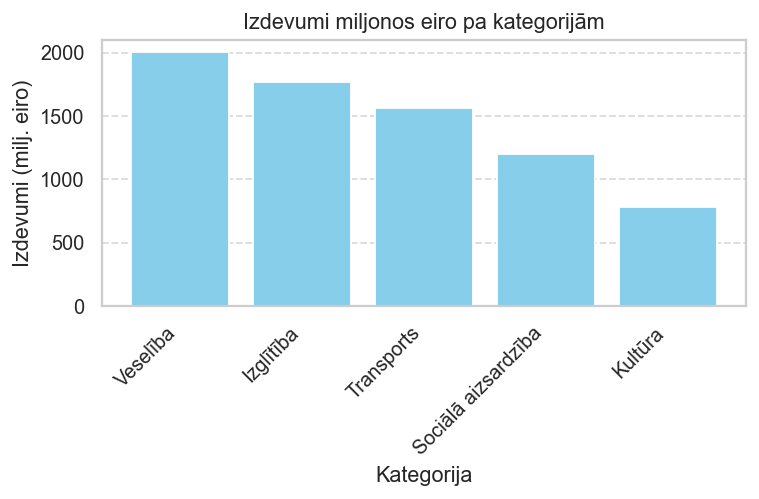

In [30]:
# tagad taisam stabiņu diagrammu ar matplotlib
plt.figure(figsize=(6, 4)) # iestatām grafika izmēru
plt.bar(izdevumi_pa_kategorijam["kategorija"], izdevumi_pa_kategorijam["izdevumi_milj_eur"], color="skyblue") # zīmējam stabiņu diagrammu
# let's turn x labels for better readability
plt.xticks(rotation=45, ha="right") # pagriežam x asu etiķetes par 45 grādiem un izlīdzinām pa labi, lai būtu labāk salasāmas
# nosaukumus un asu nosaukumi
plt.title("Izdevumi miljonos eiro pa kategorijām")
plt.xlabel("Kategorija")
plt.ylabel("Izdevumi (milj. eiro)")
# remove grid first
plt.grid(False) # noņemam režģi, jo pēc noklusējuma matplotlib pievieno režģi, bet mums tas nav vajadzīgs, tāpēc mēs to noņemam ar plt.grid(False)
# let's remove x gridlines for better readability
plt.grid(axis="y", linestyle="--", alpha=0.7) # pievienojam horizontālas režģlīnijas tikai y asij, ar punktētu stilu un nedaudz caurspīdīgām
# we want no x gridlines for better readability, so we set grid only for y axis

# fontos un izmēru arī var mainīt
# atkal saglab ar tight layout, lai nebūtu pārāk tuvu malām
plt.tight_layout()
plt.savefig("izdevumi_pa_kategorijam.png", dpi=300) # saglabājam ar labu kvalitāti
plt.show()

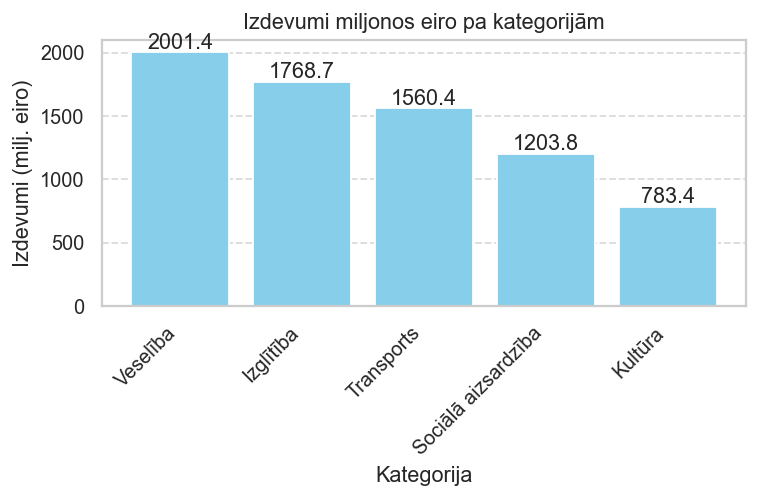

In [46]:
# tagad taisam stabiņu diagrammu ar matplotlib
plt.figure(figsize=(6, 4)) # iestatām grafika izmēru
plt.bar(izdevumi_pa_kategorijam["kategorija"], izdevumi_pa_kategorijam["izdevumi_milj_eur"], color="skyblue") # zīmējam stabiņu diagrammu
# mēs gribam parādīt vērtības katram stabiņam virs stabiņa
for index, value in enumerate(izdevumi_pa_kategorijam["izdevumi_milj_eur"]):
    plt.text(index, value, f"{value:.1f}", ha="center", va="bottom") # pievienojam tekstu virs stabiņa, kur index ir x koordināta, value ir y koordināta, f"{value:.1f}" ir teksts, kas parāda vērtību ar vienu ciparu aiz komata, ha="center" izlīdzina horizontāli uz centru, va="bottom" izlīdzina vertikāli uz apakšu, lai teksts būtu virs stabiņa
# let's turn x labels for better readability
plt.xticks(rotation=45, ha="right") # pagriežam x asu etiķetes par 45 grādiem un izlīdzinām pa labi, lai būtu labāk salasāmas
# nosaukumus un asu nosaukumi
plt.title("Izdevumi miljonos eiro pa kategorijām")
plt.xlabel("Kategorija")
plt.ylabel("Izdevumi (milj. eiro)")
# remove grid first
plt.grid(False) # noņemam režģi, jo pēc noklusējuma matplotlib pievieno režģi, bet mums tas nav vajadzīgs, tāpēc mēs to noņemam ar plt.grid(False)
# let's remove x gridlines for better readability
plt.grid(axis="y", linestyle="--", alpha=0.7) # pievienojam horizontālas režģlīnijas tikai y asij, ar punktētu stilu un nedaudz caurspīdīgām
# we want no x gridlines for better readability, so we set grid only for y axis

# fontos un izmēru arī var mainīt
# atkal saglab ar tight layout, lai nebūtu pārāk tuvu malām
plt.tight_layout()
plt.savefig("izdevumi_pa_kategorijam.png", dpi=300) # saglabājam ar labu kvalitāti
plt.show()

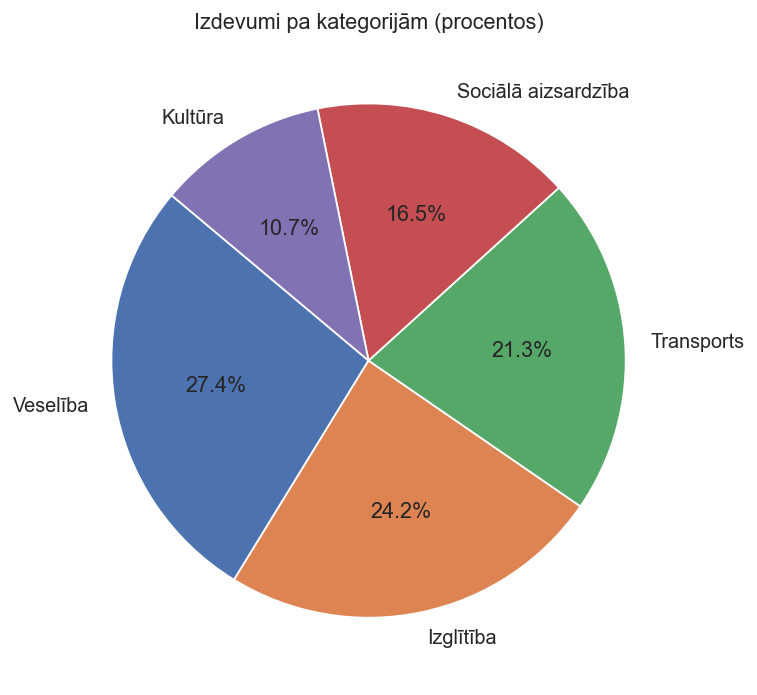

In [ ]:
# varam taisīt arī pīrāgu (pie chart)
# jāņem vērā ka pie chart nav ieteicams, ja ir daudz kategoriju, jo tas var būt grūti salasāms, bet šeit mums ir tikai 6 kategorijas, tāpēc tas ir ok.
plt.figure(figsize=(6, 6)) # iestatām grafika izmēru
plt.pie(izdevumi_pa_kategorijam["izdevumi_milj_eur"], 
        labels=izdevumi_pa_kategorijam["kategorija"], 
        autopct="%1.1f%%", 
        startangle=140) # zīmējam pie chart, autopct ir lai parādītu procentus, startangle ir lai sāktu no 140 grādiem, lai būtu labāka vizuālā izkārtojuma
# ir iespējams arī pamainīt krāsas, bet šeit mēs atstājam noklusējuma krāsas, jo tās ir pietiekami atšķirīgas un labi salasāmas

plt.title("Izdevumi pa kategorijām (procentos)")
plt.tight_layout()
plt.savefig("izdevumi_pa_kategorijam_pie.png", dpi=300) # saglabājam ar labu kvalitāti
plt.show()

### Uzdevums 4.3. Vairākas līnijas vienā grafikā

Izveidojiet grafiku, kur katra līnija rāda viena reģiona kopējos izdevumus pa gadiem.


In [32]:
df.head()

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


In [ ]:
# TODO:
# Izmantojiet pivot_table vai groupby + ciklu
# izveidosim pivot table, lai redzētu izdevumus pa gadiem un kategorijām
pivot_table = df.pivot_table(values="izdevumi_milj_eur", index="gads", columns="regions", aggfunc="sum").reset_index()
pivot_table.head()
# mēs varējam iegūt līdzīgu rezultātu ar groupby un ciklu, bet pivot_table ir ērtāks un efektīvāks veids, kā to izdarīt, jo tas ļauj mums vienkārši un ātri izveidot šādu tabulu bez nepieciešamības rakstīt papildu kodu cikliem.
# Jūsu kods šeit


regions,gads,Kurzeme,Latgale,Rīga,Vidzeme,Zemgale
0,2020,207.28,182.82,278.20,198.21,200.54
1,2021,221.12,201.53,293.71,205.74,218.89
2,2022,221.34,211.78,303.68,240.89,224.21
3,2023,241.91,215.06,339.08,219.63,238.52
4,2024,242.26,218.00,334.65,251.29,250.58


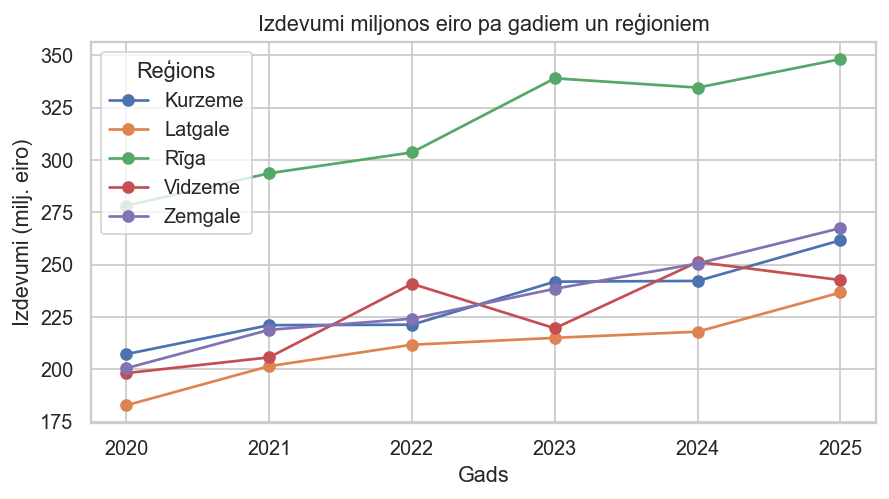

In [ ]:
# tagad mums ir pivot table
# mums ir gads kolonnā kas būs x ass
# un atlikušās kolonas mēs gribam atsevišķi zīmēt kā līnijas grafikus, 
# lai redzētu izdevumu tendences pa gadiem katram reģionam
# uzstādam grafika izmēru
plt.figure(figsize=(7, 4))
# tagad zīmējam līniju grafiku katrai reģiona kolonnai
for region in pivot_table.columns[1:]: # sākam no 1, jo 0 ir gads kolonna
    plt.plot(pivot_table["gads"], pivot_table[region], marker="o", label=region) # zīmējam līniju grafiku ar punktiem un pievienojam leģendu ar reģiona nosaukumu
# uzstādam grafika nosaukumu un asu nosaukumus
plt.title("Izdevumi miljonos eiro pa gadiem un reģioniem")
plt.xlabel("Gads")  
plt.ylabel("Izdevumi (milj. eiro)")
plt.legend(title="Reģions") # pievienojam leģendu ar nosaukumu
# leģendu var arī novietot ārpus grafika, ja ir daudz līniju, bet šeit mums ir tikai 5 reģioni, tāpēc leģenda iekšā ir ok.
plt.tight_layout()  
plt.savefig("izdevumi_pa_gadiem_un_regioniem.png", dpi=300) # saglabājam ar labu kvalitāti
plt.show()

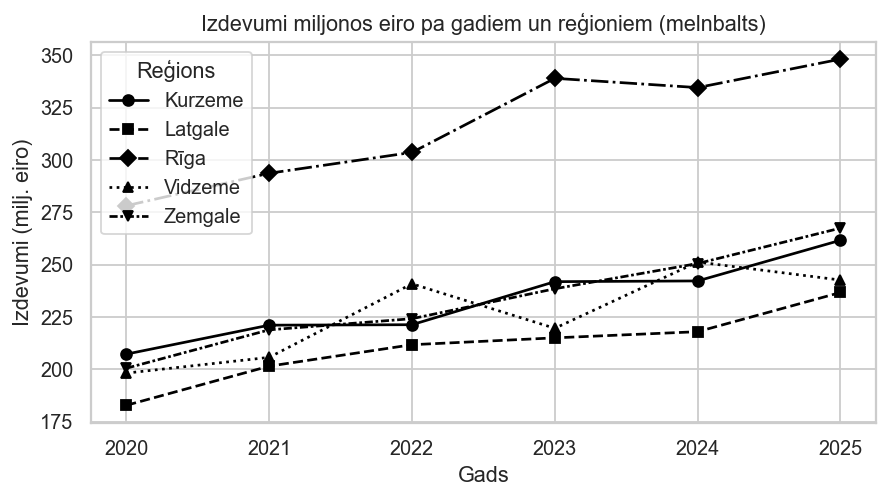

In [35]:
# ko darīt ja vajag melnbaltai publikācijai šadas 5 līnijas, lai tās būtu atšķiramas?
#  Var izmantot dažādus stilu un markerus, piemēram:
plt.figure(figsize=(7, 4))
styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))] # dažādi līniju stili
markers = ["o", "s", "D", "^", "v"] # dažādi markeru stili
colors = ["black"] * len(pivot_table.columns[1:]) # visas līnijas melnas

for i, region in enumerate(pivot_table.columns[1:]): # sākam no 1, jo 0 ir gads kolonna
    plt.plot(pivot_table["gads"], pivot_table[region], # x un y vērtības
             linestyle=styles[i % len(styles)], # izvēlamies līnijas stilu no saraksta, izmantojot modulo operatoru, lai atkārtotu stilus, ja ir vairāk reģionu nekā stilu
             marker=markers[i % len(markers)], # izvēlamies markeru stilu no saraksta, izmantojot modulo operatoru, lai atkārtotu stilus, ja ir vairāk reģionu nekā markeru
             color=colors[i], # izvēlamies krāsu no saraksta
             label=region) # zīmējam līniju grafiku ar punktiem un pievienojam leģendu ar reģiona nosaukumu
    
plt.title("Izdevumi miljonos eiro pa gadiem un reģioniem (melnbalts)")
plt.xlabel("Gads")
plt.ylabel("Izdevumi (milj. eiro)")
plt.legend(title="Reģions")
plt.tight_layout()
plt.savefig("izdevumi_pa_gadiem_un_regioniem_melnbalts.png", dpi=300)
plt.show()  


## 5. Seaborn statistiskās vizualizācijas

Seaborn ir īpaši ērts statistisku sadalījumu un salīdzinājumu attēlošanai.


### Uzdevums 5.1. Histogramma

Izveidojiet histogrammu kolonnai `iedzivotaju_apmierinatiba`.

**Prasības:**
- izmantojiet `sns.histplot`,
- norādiet binu skaitu,
- pievienojiet nosaukumu.


In [36]:
# apskatam atkal mūsu sākotnējo DataFrame, lai redzētu kādi ir dati
df.head()

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


In [38]:
# kāda bija statistik par iedzīvotāju apmierinātību ar dzīvi?
df["iedzivotaju_apmierinatiba"].describe() # statistika tika par vienu kolonnu

count    150.000000
mean      72.535333
std        6.730718
min       56.200000
25%       67.325000
50%       72.100000
75%       77.275000
max       87.700000
Name: iedzivotaju_apmierinatiba, dtype: float64

In [43]:
plt.rcParams["font.size"] # cik liels ir bāzes fonta izmērs


12.0

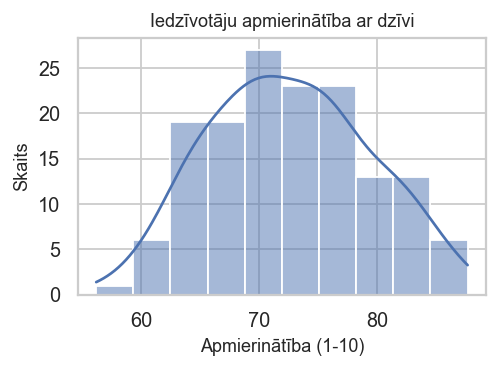

In [45]:
# Jūsu histogrammas kods šeit
# mums jau ir importēts seaborn kā sns, tāpēc varam izmantot sns.histplot funkciju, lai uzzīmētu histogrammu iedzīvotāju apmierinātībai ar dzīvi
plt.figure(figsize=(4, 3)) # iestatām grafika izmēru
sns.histplot(df["iedzivotaju_apmierinatiba"], bins=10, kde=True) # zīmējam histogrammu ar 10 binu un pievienojam KDE līniju, lai redzētu datu sadalījumu
# samazinam arī nosaukumu fontu, lai būtu labāk salasāms
# izvēlamies bāzes fonta izmēru un samazinām to par 2, lai būtu labāk salasāms
base_fontsize = plt.rcParams["font.size"] # iegūstam bāzes fonta izmēru
plt.title("Iedzīvotāju apmierinātība ar dzīvi", fontsize=base_fontsize - 2) # samazinām nosaukuma fonta izmēru par 2, lai būtu labāk salasāms
plt.xlabel("Apmierinātība (1-10)", fontsize=base_fontsize - 2) # samazinām x ass nosaukuma fonta izmēru par 2, lai būtu labāk salasāms
plt.ylabel("Skaits", fontsize=base_fontsize - 2) # samazinām y ass nosaukuma fonta izmēru par 2, lai būtu labāk salasāms
plt.tight_layout()
plt.savefig("iedzivotaju_apmierinatiba_histogramma.png", dpi=300)
plt.show()


### Uzdevums 5.2. Boxplot pa kategorijām

Izveidojiet boxplot, kas salīdzina iedzīvotāju apmierinātību dažādās kategorijās.

Vairāk par boxplot: https://en.wikipedia.org/wiki/Box_plot
Seaborn dokumentācija: https://seaborn.pydata.org/generated/seaborn.boxplot.html


In [47]:
df.head()

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


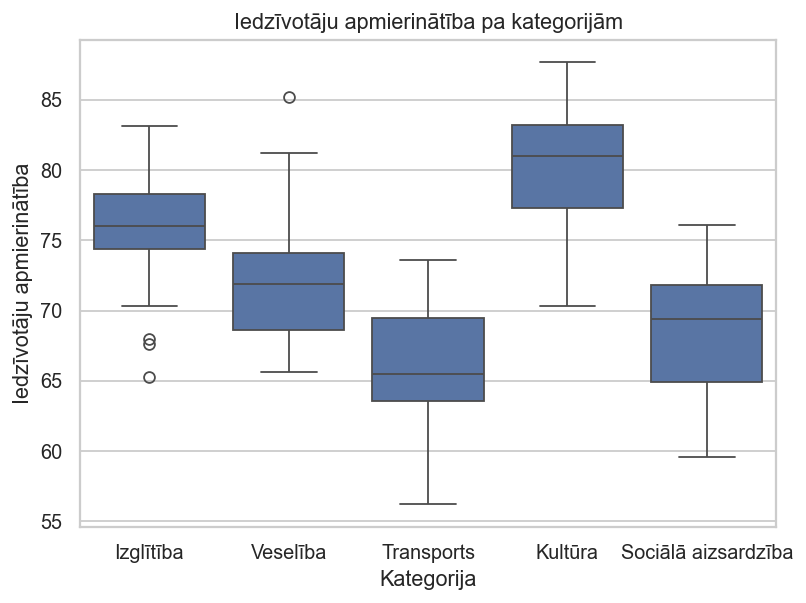

In [48]:
# Jūsu boxplot kods šeit
# lietosim sns.boxplot
# dati būs no oriģinālā df
sns.boxplot(data=df,
            x="kategorija",
            y="iedzivotaju_apmierinatiba")
# title
plt.title("Iedzīvotāju apmierinātība pa kategorijām")
# xlabel
plt.xlabel("Kategorija")
# ylabel
plt.ylabel("Iedzīvotāju apmierinātība")
# tight layout
plt.tight_layout()
# saglabājam
plt.savefig("boxplot_kategorijas.png")
plt.show()


### Uzdevums 5.3. Scatter plot

Izveidojiet izkliedes grafiku, kur:
- x ass = `izdevumi_milj_eur`
- y ass = `iedzivotaju_apmierinatiba`
- krāsa = `kategorija`


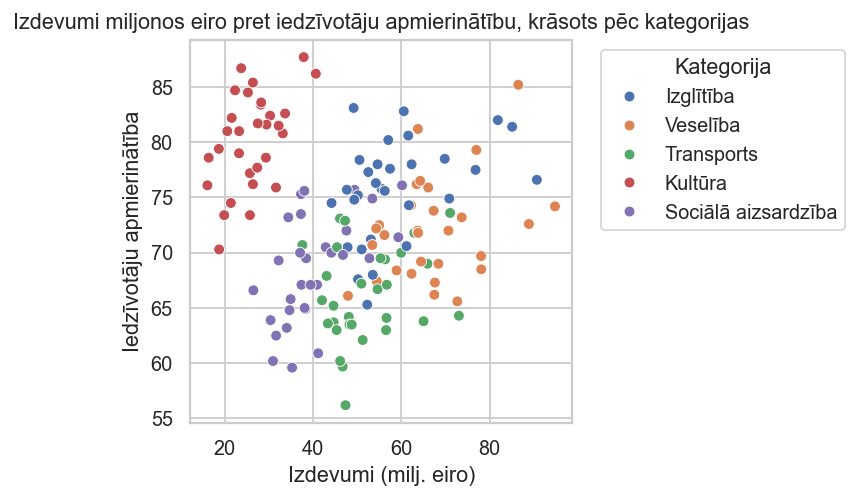

In [53]:
# TODO:
# tātad mēs attēlojam izdevumi_milj_eur pret iedzivotaju_apmierinatiba
# bet papildu krāsojam pēc kategorijas
# mēs divas dimensijās attēlojām trīs dimensiju datus
# Jūsu scatterplot kods šeit
# lietosim sns.scatterplot
# pamainam izmēru vispirms
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df,
                x="izdevumi_milj_eur",
                y="iedzivotaju_apmierinatiba",
                hue="kategorija")
# pielikam savus nosaukumus un saglabājam
plt.title("Izdevumi miljonos eiro pret iedzīvotāju apmierinātību, krāsots pēc kategorijas")
plt.xlabel("Izdevumi (milj. eiro)")
plt.ylabel("Iedzīvotāju apmierinātība")
# izvirzam ārā leģenu uz labo pusi augšu
plt.legend(title="Kategorija", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("scatterplot_izdevumi_pret_apmierinatibu.png", dpi=300)
plt.show()



### Uzdevums 5.4. Korelāciju heatmap

Izveidojiet korelāciju matricu tikai skaitliskajām kolonnām un attēlojiet to ar `sns.heatmap`.


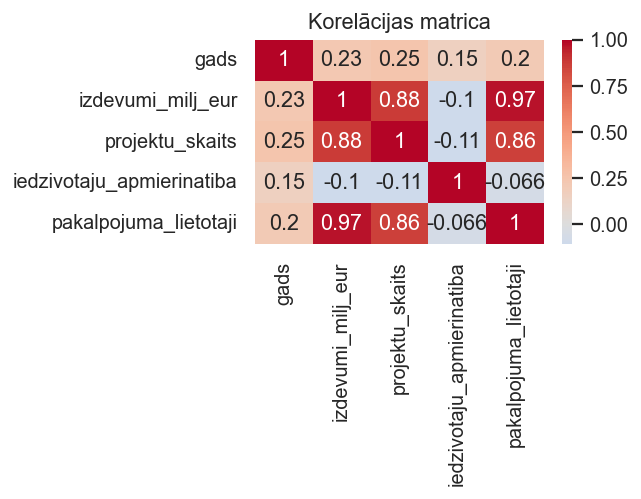

In [55]:
# TODO:
# 1. Atlasiet skaitliskās kolonnas
numeric_df = df.select_dtypes(include=[np.number]) # atlasām tikai skaitliskās kolonnas, lai varētu aprēķināt korelāciju
# 2. Aprēķiniet korelāciju matricu
correlation_matrix = numeric_df.corr()
# 3. Uzzīmējiet heatmap

# Jūsu kods šeit
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Korelācijas matrica")
plt.tight_layout()
plt.savefig("korelacija_heatmap.png", dpi=300)
plt.show()


## Korelācija nenozīme causation

Korelācijas pašas par sevi nenozīme ciešu likumsakarību!

## 6. Interaktīvās vizualizācijas ar Plotly

Šeit uzdevums ir sajust atšķirību starp statiskiem un interaktīviem grafikiem.


### Uzdevums 6.1. Interaktīvs līniju grafiks

Ar Plotly izveidojiet interaktīvu grafiku kopējiem izdevumiem pa gadiem.


In [57]:
# TODO:
# Ieteikums: izmantojiet px.line(...)

fig = px.line(izdevumi_pa_gadiem, 
              x="gads", y="izdevumi_milj_eur", 
              markers=True, 
              title="Izdevumi miljonos eiro pa gadiem")

fig.show()



### Uzdevums 6.2. Interaktīvs stabiņu grafiks

Izveidojiet interaktīvu stabiņu grafiku izdevumiem pa kategorijām.


In [ ]:
# TODO:
# Jūsu Plotly bar chart kods šeit


### Uzdevums 6.3. Interaktīvs scatter plot

Izveidojiet Plotly scatter plot ar:
- krāsu pēc kategorijas,
- punkta izmēru pēc projektu skaita,
- hover informāciju par gadu un reģionu.


In [ ]:
# TODO:
# Jūsu Plotly scatter kods šeit


## 7. Prezentācijām piemēroti grafiki

Aplūkojiet savus iepriekš veidotos grafikus un uzlabojiet vismaz vienu no tiem tā, lai tas būtu piemērots prezentācijai.

### Pārbaudiet:
- vai virsraksts ir skaidrs;
- vai etiķetes ir salasāmas;
- vai nav pārāk daudz vizuāla trokšņa;
- vai ir saprotams galvenais vēstījums.


In [ ]:
# TODO:
# Izvēlieties vienu iepriekšējo grafiku un uzlabojiet to prezentācijai

# Jūsu kods šeit


## 8. Mini projekts

Izveidojiet 3 grafikus:
1. **Matplotlib** — tendence laikā;
2. **Seaborn** — sadalījums vai salīdzinājums;
3. **Plotly** — interaktīva izpēte.

Pie katra grafikā zemāk uzrakstiet īsu interpretāciju:
- ko grafiks rāda,
- kāds ir galvenais secinājums.


In [ ]:
# TODO:
# 1. Matplotlib grafiks
# 2. Seaborn grafiks
# 3. Plotly grafiks
# 4. Tekstiska interpretācija Markdown šūnā zem šīs šūnas


## 9. Pašpārbaudes jautājumi

1. Kad labāk izmantot līniju grafiku, nevis stabiņu grafiku?
2. Kādos gadījumos Seaborn ir ērtāks par Matplotlib?
3. Kāda ir Plotly galvenā priekšrocība?
4. Kāpēc korelācija vēl nenozīmē cēloņsakarību?
5. Kādas ir 3 biežākās kļūdas sliktā grafikā?
